
# GH2 Chile — LCA Results Notebook  v11c
### Wind–Methanol vs Solar–Ammonia · Focus Impacts · Publication Figures

**Paper:** *Regional LCA of Green Hydrogen Export from Chile*  
**Authors:** Alan Pino, Adolfo Uribe · ECOS 2026

---

**What this notebook does, and why it is fast:**

1. Builds the Brightway foreground model (same as v11)  
2. Runs LCIA for **6 focus impact categories** (54 LCA runs total)  
3. Computes site-specific results using **direct foreground LCA**  
   — instead of recursive terminal decomposition (~500 runs in v11b),  
   we pre-compute electricity & water stage factors once per pathway  
   (2 × 3 pathways × 6 impacts = 36 extra runs; total ≈ 90 runs)  
4. Produces **6 publication-quality figures**

**Two calculation modes (same as v11):**

| Mode | Label in plots | Description |
|---|---|---|
| `generic_proxy` | *(sensitivity)* | ecoinvent CL national-average electricity |
| `site_specific` | *(recommended)* | Project-specific CF: Magallanes 57%, Antofagasta solar |

**Color palette (Okabe-Ito, colorblind-safe, print-safe):**

| Pathway | Color | Hatch |
|---|---|---|
| MAG wind → biogenic methanol | `#0072B2` blue | none |
| MAG wind → DAC methanol | `#D55E00` vermillion | `///` |
| MEJ solar → ammonia | `#009E73` green | `..` |


## 0 · Settings — edit here only

In [1]:

from pathlib import Path
import re, math, warnings
from collections import defaultdict
import numpy as np
import pandas as pd
from openpyxl import load_workbook

try:
    import brightway2 as bw
    BW_AVAILABLE = True
except Exception as e:
    BW_AVAILABLE = False
    print("Brightway unavailable:", e)

# ── Paths ─────────────────────────────────────────────────────────────────────
OUT = Path("outputs_v11c"); OUT.mkdir(exist_ok=True)
SITE_FACTORS_FILE = Path("GH2_ECOS_data.xlsx")

# ── Brightway ─────────────────────────────────────────────────────────────────
BW_PROJECT   = "M23feb2025"
SOURCE_DB    = "Base2020_toH2_v2"
FG_DB        = "GH2_Chile_v11c"
RESET_FG_DB  = True
AUTO_PROXY   = True

# ── Focus impact categories (change this list to add/remove) ──────────────────
# Full v11 runs all 27 EF categories. Here we focus on the 6 most policy-relevant.
FOCUS = [
    "Climate change",                    # kg CO2-eq  — primary metric
    "Particulate matter",                # disease incidence
    "Water use",                         # m3 water deprivation
    "Resource use, fossils",             # MJ fossil
    "Land use",                          # Pt soil quality
    "Resource use, minerals and metals", # kg Sb-eq
]

# ── Sanity gate threshold ─────────────────────────────────────────────────────
SANITY_CC_MAX = 50.0   # kg CO2eq per 1 unit of proxy

# ── Plot settings ─────────────────────────────────────────────────────────────
DPI = 220

# Okabe-Ito colorblind-safe palette
C = {
    "biogenic" : "#0072B2",   # blue
    "dac"      : "#D55E00",   # vermillion
    "ammonia"  : "#009E73",   # green
    "grey_h2"  : "#999999",
    "blue_h2"  : "#56B4E9",
}
HATCH = {"biogenic":"", "dac":"///", "ammonia":".."}

print(f"BW available : {BW_AVAILABLE}")
print(f"Output dir   : {OUT.resolve()}")
print(f"Focus impacts: {FOCUS}")


BW available : True
Output dir   : C:\Users\uribep_a\OneDrive - Paul Scherrer Institut\general_LCA\outputs_v11c
Focus impacts: ['Climate change', 'Particulate matter', 'Water use', 'Resource use, fossils', 'Land use', 'Resource use, minerals and metals']



---
## 1 · Site-specific EF 3.1 factors

Loaded from `GH2_ECOS_data.xlsx` using the **canonical 27-category taxonomy**
(from v11). Row position disambiguates duplicate SimaPro labels.


In [2]:

# ── Canonical taxonomy (row-position-based disambiguation) ────────────────────
# Only the fields needed for loading and matching are kept here.
# Full taxonomy with notes is in v11; this notebook inherits those definitions.
CANONICAL_ROWS = [
    (1,  "Acidification"),
    (2,  "Climate change"),
    (3,  "Climate change, biogenic"),
    (4,  "Climate change, fossil"),
    (5,  "Climate change, land use"),
    (6,  "Ecotoxicity, freshwater (total)"),
    (7,  "Ecotoxicity, freshwater, metals/inorganics"),
    (8,  "Ecotoxicity, freshwater, inorganics"),
    (9,  "Ecotoxicity, freshwater, organics"),
    (10, "Ecotoxicity, freshwater, organics (detail)"),
    (11, "Particulate matter"),
    (12, "Eutrophication, marine"),
    (13, "Eutrophication, freshwater"),
    (14, "Eutrophication, terrestrial"),
    (15, "Human toxicity, cancer (total)"),
    (16, "Human toxicity, cancer, inorganics"),
    (17, "Human toxicity, cancer, organics"),
    (18, "Human toxicity, non-cancer (total)"),
    (19, "Human toxicity, non-cancer, inorganics"),
    (20, "Human toxicity, non-cancer, organics"),
    (21, "Ionising radiation"),
    (22, "Land use"),
    (23, "Ozone depletion"),
    (24, "Photochemical ozone formation"),
    (25, "Resource use, fossils"),
    (26, "Resource use, minerals and metals"),
    (27, "Water use"),
]
CANONICAL_NAMES = [c for _,c in CANONICAL_ROWS]


def load_ef_sheet(path, sheet, col_offset=0):
    # Load 27 EF factor values, assign canonical names by row position.
    wb = load_workbook(path, read_only=True, data_only=True)
    ws = wb[sheet]
    hdr, ic = None, None
    for row in ws.iter_rows():
        for cell in row:
            if cell.value and str(cell.value).strip() == "Impact category":
                hdr, ic = cell.row, cell.column; break
        if hdr: break
    values = {}
    data_rows = []
    for row in ws.iter_rows(min_row=hdr+1, values_only=True):
        cat = row[ic-1]
        if not cat or str(cat).strip() in ("","nan","None"): continue
        nums = [float(v) for v in row[ic+1:] if v is not None and isinstance(v,(int,float))]
        data_rows.append(nums[col_offset] if len(nums)>col_offset else None)
    if len(data_rows) != 27:
        raise ValueError(f"Sheet {sheet!r}: expected 27 rows, got {len(data_rows)}")
    return {name: val for (_,name), val in zip(CANONICAL_ROWS, data_rows)}


SITE_FACTORS = pd.DataFrame({
    "wind_per_kwh" : load_ef_sheet(SITE_FACTORS_FILE, "wind"),
    "solar_per_kwh": load_ef_sheet(SITE_FACTORS_FILE, "solar"),
    "water_per_kg" : load_ef_sheet(SITE_FACTORS_FILE, "water"),
})
SITE_UNITS = {
    "Climate change":"kg CO\u2082-eq","Particulate matter":"disease inc.",
    "Water use":"m\u00b3 depriv.","Resource use, fossils":"MJ",
    "Land use":"Pt","Resource use, minerals and metals":"kg Sb-eq",
}

print(f"Site factors loaded: {len(SITE_FACTORS)} canonical categories")
assert abs(SITE_FACTORS.loc["Climate change","wind_per_kwh"] - 0.005841702) < 1e-6
print("Spot check passed: CC wind = 0.00584 kg CO2/kWh")
print()
print("Focus category site factors:")
for cat in FOCUS:
    r = SITE_FACTORS.loc[cat]
    print(f"  {cat:<40s}: wind={r.wind_per_kwh:.3e}  solar={r.solar_per_kwh:.3e}  water={r.water_per_kg:.3e}")


Site factors loaded: 27 canonical categories
Spot check passed: CC wind = 0.00584 kg CO2/kWh

Focus category site factors:
  Climate change                          : wind=5.842e-03  solar=2.160e-02  water=2.330e-03
  Particulate matter                      : wind=6.228e-10  solar=1.407e-09  water=1.010e-10
  Water use                               : wind=2.274e-03  solar=1.319e-02  water=4.400e-04
  Resource use, fossils                   : wind=6.614e-02  solar=2.647e-01  water=2.780e-02
  Land use                                : wind=6.228e-02  solar=2.330e+00  water=5.220e-03
  Resource use, minerals and metals       : wind=7.121e-07  solar=1.709e-06  water=1.470e-08


## 2 · Project parameters and stoichiometry

In [3]:

MW = {"H2":2.01588,"CO2":44.0095,"MeOH":32.0419,"N2":28.0134,"NH3":17.0305}
CARRIER = {
    "methanol":{"kg_c":MW["MeOH"]/(3*MW["H2"]),"kg_co2":MW["CO2"]/(3*MW["H2"]),"kg_n2":0.0},
    "ammonia" :{"kg_c":2*MW["NH3"]/(3*MW["H2"]),"kg_co2":0.0,"kg_n2":MW["N2"]/(3*MW["H2"])},
}
ELEC_KWH = {
    "MAG_WIND_METHANOL": (242e3*5000)/(27830e3),  # 43.47 kWh/kg H2 (project KPI)
    "MEJ_SOLAR_AMMONIA": 50.0,                     # IEA 2023 PEM central estimate
}
SYNTH_KWH = {"methanol":0.50,"ammonia":0.60}
KWH_TOTAL = {
    "MAG_WIND_METHANOL": ELEC_KWH["MAG_WIND_METHANOL"] + CARRIER["methanol"]["kg_c"]*SYNTH_KWH["methanol"],
    "MEJ_SOLAR_AMMONIA": ELEC_KWH["MEJ_SOLAR_AMMONIA"] + CARRIER["ammonia"]["kg_c"]*SYNTH_KWH["ammonia"],
}
WATER_KG_DESAL = {"MAG_WIND_METHANOL":10.0,"MEJ_SOLAR_AMMONIA":10.0*0.15}

PROJECTS = {
    "MAG_WIND_METHANOL": {
        "label":"Magallanes: wind -> H2 -> methanol",
        "site":"Tehuel Aike / Cabo Negro", "region":"Magallanes",
        "origin_port":"Puerto Cabo Negro","renewable":"wind_onshore",
        "carrier":"methanol","co2_cases":["biogenic","dac"],
        "water_mix":{"desalination":1.00,"wastewater_reuse":0.00},
        "site_col":"wind_per_kwh","cap_factor":0.57,
    },
    "MEJ_SOLAR_AMMONIA": {
        "label":"Mejillones: solar PV -> H2 -> ammonia",
        "site":"Mejillones","region":"Antofagasta",
        "origin_port":"Puerto Mejillones","renewable":"solar_pv",
        "carrier":"ammonia","co2_cases":[None],
        "water_mix":{"desalination":0.15,"wastewater_reuse":0.85},
        "site_col":"solar_per_kwh","cap_factor":0.0,
    },
}
ROUTES = pd.DataFrame([
    ["Puerto Cabo Negro",  "Los Angeles",   10898],
    ["Puerto Cabo Negro",  "Rotterdam",     13873],
    ["Puerto Cabo Negro",  "Kansai (Kobe)", 22426],
    ["Puerto Mejillones",  "Los Angeles",    8141],
    ["Puerto Mejillones",  "Rotterdam",     11062],
    ["Puerto Mejillones",  "Kansai (Kobe)", 23703],
], columns=["origin_port","destination","distance_km"])

print("kWh/kg H2-eq (electrolysis + synthesis):")
for pid,kwh in KWH_TOTAL.items():
    print(f"  {pid}: {kwh:.2f}  ({ELEC_KWH[pid]:.2f} + {kwh-ELEC_KWH[pid]:.2f})")


kWh/kg H2-eq (electrolysis + synthesis):
  MAG_WIND_METHANOL: 46.13  (43.48 + 2.65)
  MEJ_SOLAR_AMMONIA: 53.38  (50.00 + 3.38)


## 3 · Brightway helpers

In [4]:

if not BW_AVAILABLE: raise ImportError("Run in your Brightway environment.")
bw.projects.set_current(BW_PROJECT)
if SOURCE_DB not in bw.databases:
    raise ValueError(f"{SOURCE_DB!r} not found.")
source_db = bw.Database(SOURCE_DB)
print(f"BW project: {bw.projects.current}  |  Source DB: {SOURCE_DB} ({len(source_db)} acts)")

def norm(x): return re.sub(r"\s+", " ", str(x).lower()).strip()
def norm_unit(u):
    u = re.sub(r"\s+", " ", str(u).lower()).strip()
    return {"ton kilometer":"tonne kilometre","tonne kilometer":"tonne kilometre",
            "ton kilometre":"tonne kilometre","tkm":"tonne kilometre",
            "kg":"kilogram","kwh":"kilowatt hour","m3":"cubic meter",
            "m\u00b3":"cubic meter"}.get(u, u)
def act_txt(a): return " | ".join([a.get("name",""),a.get("reference product",""),a.get("location",""),a.get("unit","")])

_pclog = []
def find_cands(db, include=None, exclude=None, unit=None, preferred_unit=None, limit=20):
    inc=[norm(t) for t in (include or [])]; exc=[norm(t) for t in (exclude or [])]
    un=norm_unit(unit) if unit else None; pref=norm_unit(preferred_unit) if preferred_unit else None
    rows=[]
    for act in db:
        txt=norm(act_txt(act)); au=norm_unit(act.get("unit","")); al=norm(act.get("location",""))
        if inc and not all(t in txt for t in inc): continue
        if exc and any(t in txt for t in exc): continue
        if un and au!=un: continue
        sc=0
        if pref and au==pref: sc+=100
        if al=="cl": sc+=50
        elif al in {"glo","row","rla"}: sc+=20
        for kw in [">3mw","onshore","seawater","reverse osmosis","photovoltaic","multi-si","liquid goods","ultrafiltration"]: sc+=5*(kw in txt)
        for kw in ["<1mw","0.28kwp","gaas","facade","building-integrated","residential"]: sc-=30*(kw in txt)
        rows.append({"sc":sc,"key":act.key,"name":act.get("name"),"loc":act.get("location"),"unit":act.get("unit")})
    if not rows: return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(["sc","name"],ascending=[False,True]).head(limit)

def sel_proxy(db, label, strats, fallback=None):
    for s in strats:
        cands = find_cands(db, include=s.get("include",[]),exclude=s.get("exclude",[]),
                           unit=s.get("unit"),preferred_unit=s.get("preferred_unit"),limit=15)
        if cands.empty: continue
        _pclog.append(cands.assign(proxy_label=label))
        ch = bw.get_activity(tuple(cands.iloc[0]["key"]))
        print(f"  {label:<35s}-> {ch['name']!r} | {ch.get('location')} | {ch.get('unit')}")
        return ch
    print(f"  {label:<35s}-> None (zero burden assumed)")
    return fallback

def mk(db, code, name, unit, loc="CL", ref=None):
    key=(db.name,code)
    if key in db:
        act=bw.get_activity(key)
        for e in list(act.exchanges()): e.delete()
    else:
        act=db.new_activity(code=code,name=name,unit=unit,location=loc)
        act["reference product"]=ref or name; act.save()
    act.new_exchange(input=act.key,amount=1.0,type="production",unit=unit).save()
    return act

def addx(act, inp, amount, unit=None, comment=None):
    if inp is None: return
    e=act.new_exchange(input=inp.key,amount=float(amount),type="technosphere")
    if unit: e["unit"]=unit
    if comment: e["comment"]=comment
    e.save()

def lcia(act, method, amount=1.0):
    l=bw.LCA({act:amount},method); l.lci(); l.lcia(); return float(l.score)

if FG_DB in bw.databases and RESET_FG_DB: del bw.databases[FG_DB]
if FG_DB not in bw.databases: bw.Database(FG_DB).write({})
fg=bw.Database(FG_DB)
print(f"Foreground DB: {FG_DB}")


BW project: M23feb2025  |  Source DB: Base2020_toH2_v2 (31674 acts)
Foreground DB: GH2_Chile_v11c


## 4 · Select proxies and run sanity check

In [5]:

print("Selecting proxies..."); print()
PX = {}
PX["solar_pv"] = sel_proxy(source_db, "solar_pv", [
    {"include":["electricity production","photovoltaic","3kwp","multi-si"],"exclude":["gaas","0.28kwp","facade","market"],"unit":"kilowatt hour"},
    {"include":["electricity production","photovoltaic","3kwp"],"exclude":["gaas","0.28kwp","facade","market"],"unit":"kilowatt hour"},
    {"include":["electricity production","photovoltaic"],"exclude":["0.28kwp","gaas","market","residential","facade"],"unit":"kilowatt hour"},
    {"include":["electricity","photovoltaic"],"exclude":["0.28kwp","gaas","market","residential"],"preferred_unit":"kilowatt hour"},
])
PX["wind_onshore"] = sel_proxy(source_db, "wind_onshore", [
    {"include":["electricity production","wind",">3mw","onshore"],"exclude":["market","offshore","<1mw"],"unit":"kilowatt hour"},
    {"include":["electricity production","wind","onshore"],"exclude":["market","offshore","<1mw"],"unit":"kilowatt hour"},
    {"include":["electricity production","wind"],"exclude":["market","offshore"],"preferred_unit":"kilowatt hour"},
])
PX["desalination"] = sel_proxy(source_db, "desalination", [
    {"include":["tap water production","seawater","ultrafiltration"],"preferred_unit":"kilogram"},
    {"include":["tap water production","seawater reverse osmosis"],"preferred_unit":"kilogram"},
    {"include":["seawater","reverse osmosis"],"preferred_unit":"kilogram"},
])
PX["wastewater_reuse"] = sel_proxy(source_db, "wastewater_reuse", [
    {"include":["treatment","wastewater","municipal"],"exclude":["leachate","slf","landfill","condensate","boiler"],"unit":"cubic meter"},
    {"include":["treatment","wastewater"],"exclude":["leachate","slf","landfill","condensate","boiler","industrial"],"unit":"cubic meter"},
])  # fallback=None (zero burden)

N2_BAN=["tetroxide","dioxide","oxide","monoxide","nitrous","nitric","nitrate","fertiliser",
        "ammonia","nutrient","liquid","fluoride","trifluoride","nf3","pf5"]
def find_n2(db):
    rows=[]
    for act in db:
        n=norm(act.get("name","")); r=norm(act.get("reference product","")); u=norm(act.get("unit",""))
        txt=f"{n} {r}"
        if "nitrogen" not in txt or u!="kilogram" or "liquid" in r: continue
        if any(b in txt for b in N2_BAN): continue
        sc=150*("gaseous" in r or "gaseous" in n)+100*("air separation" in n)+80*("nitrogen production" in n)+50*("market for nitrogen" in n)
        sc+=15*(norm(act.get("location","")) in {"glo","row","rla","cl"})
        rows.append({"sc":sc,"key":act.key,"name":act.get("name"),"loc":act.get("location")})
    if not rows: return None
    cands=pd.DataFrame(rows).sort_values(["sc","name"],ascending=[False,True]).head(10)
    chosen=bw.get_activity(tuple(cands.iloc[0]["key"]))
    bad=any(b in (chosen.get("name","")+chosen.get("reference product","")).lower() for b in ["fluoride","oxide","liquid","nf3"])
    if bad: return None
    print(f"  {'nitrogen_gas':<35s}-> {chosen.get('name')!r} | {chosen.get('location')}")
    return chosen
PX["nitrogen"] = find_n2(source_db)

for lbl,strats in [
    ("co2_dac",[{"include":["carbon dioxide","capture","atmosphere"],"preferred_unit":"kilogram"},
                {"include":["direct air capture"],"preferred_unit":"kilogram"},
                {"include":["carbon dioxide","capture"],"preferred_unit":"kilogram"}]),
    ("co2_biogenic",[{"include":["carbon dioxide","biogenic"],"preferred_unit":"kilogram"},
                     {"include":["carbon dioxide","capture","biomass"],"preferred_unit":"kilogram"},
                     {"include":["carbon dioxide","capture"],"preferred_unit":"kilogram"}]),
]:
    try: PX[lbl]=sel_proxy(source_db,lbl,strats)
    except: PX[lbl]=PX.get("co2_dac")

PX["transport_methanol"] = sel_proxy(source_db, "transport_methanol", [
    {"include":["transport","freight","sea","liquid goods","other than petroleum"],"preferred_unit":"tonne kilometre"},
    {"include":["transport","freight","sea","chemical"],"preferred_unit":"tonne kilometre"},
    {"include":["transport","freight","sea","tanker"],"exclude":["crude","liquefied natural gas","lng"],"preferred_unit":"tonne kilometre"},
    {"include":["transport","freight","sea"],"preferred_unit":"tonne kilometre"},
])
PX["transport_ammonia"] = sel_proxy(source_db, "transport_ammonia", [
    {"include":["transport","freight","sea","liquefied natural gas"],"preferred_unit":"tonne kilometre"},
    {"include":["transport","freight","sea","tanker"],"preferred_unit":"tonne kilometre"},
    {"include":["transport","freight","sea"],"preferred_unit":"tonne kilometre"},
])

# ── Sanity gate ───────────────────────────────────────────────────────────────
_cc_m = next((m for m in bw.methods
              if all(s in " | ".join(map(str,m)).lower()
                     for s in ["ef v3.1 no lt","climate change no lt"])
              and not any(s in " | ".join(map(str,m)).lower()
                          for s in ["biogenic","fossil","land use"])), None)
print(f"\nSanity gate CC method: {_cc_m}")
for lbl, px in list(PX.items()):
    if px is None: print(f"  {lbl:<35s}: SKIP (None)"); continue
    try: cc=lcia(px,_cc_m)
    except: cc=float("nan")
    if abs(cc) > SANITY_CC_MAX:
        warnings.warn(f"SANITY FAIL {lbl!r}: CC={cc:.2f} -> set to None"); PX[lbl]=None
        print(f"  {lbl:<35s}: FAIL CC={cc:.2f} -> None")
    else: print(f"  {lbl:<35s}: OK   CC={cc:.4g}")


Selecting proxies...

  solar_pv                           -> 'electricity production, photovoltaic, 3kWp slanted-roof installation, multi-Si, panel, mounted' | CL | kilowatt hour
  wind_onshore                       -> 'electricity production, wind, >3MW turbine, onshore' | CL | kilowatt hour
  desalination                       -> 'tap water production, seawater reverse osmosis, ultrafiltration pretreatment, baseline module, single stage' | GLO | kilogram
  wastewater_reuse                   -> 'treatment of heat carrier liquid, 40% C3H8O2, wastewater treatment' | RoW | cubic meter
  co2_dac                            -> 'carbon dioxide, captured from atmosphere and stored, with a solvent-based direct air capture system, 1MtCO2' | RER | kilogram
  co2_biogenic                       -> 'carbon dioxide, captured from biomass' | CL | kilogram
  transport_methanol                 -> 'market for transport, freight, sea, tanker for liquid goods other than petroleum and liquefied natural ga

C:\Users\uribep_a\AppData\Local\Temp\ipykernel_21076\2759835926.py:80: UserWarning: SANITY FAIL 'wastewater_reuse': CC=-969.00 -> set to None
  warnings.warn(f"SANITY FAIL {lbl!r}: CC={cc:.2f} -> set to None"); PX[lbl]=None


  wastewater_reuse                   : FAIL CC=-969.00 -> None
  nitrogen                           : SKIP (None)
  co2_dac                            : OK   CC=0.5998
  co2_biogenic                       : OK   CC=0.3191
  transport_methanol                 : OK   CC=0.008122
  transport_ammonia                  : OK   CC=0.008122


## 5 · Build foreground model

In [6]:

fa = {}  # foreground activities registry

# Electricity wrappers (1 kWh generic proxy)
for pid, cfg in PROJECTS.items():
    a = mk(fg, f"elec_{pid.lower()}", f"Electricity, {cfg['renewable']}, {cfg['site']}", "kilowatt hour","CL","electricity, high voltage")
    addx(a, PX[cfg["renewable"]], 1.0, unit="kilowatt hour", comment=f"Generic CL proxy. Site-specific uses GH2_ECOS_data.xlsx instead.")
    fa[f"elec_{pid.lower()}"] = a

# Water mix (FU = 1 kg water)
for pid, cfg in PROJECTS.items():
    a = mk(fg, f"water_{pid.lower()}", f"Water supply mix, {cfg['site']}", "kilogram","CL","water, supply mix")
    for wt, share in cfg["water_mix"].items():
        if share > 0 and PX.get(wt):
            addx(a, PX[wt], share, unit="kilogram", comment=f"{wt}: {share:.0%} (proxy FU=1kg)")
        elif share > 0:
            print(f"  Note: {wt} proxy=None -> zero burden for {share:.0%} at {cfg['site']}")
    fa[f"water_{pid.lower()}"] = a

# H2 electrolysis (FU = 1 kg H2)
for pid, cfg in PROJECTS.items():
    a = mk(fg, f"h2_{pid.lower()}", f"H2 electrolysis, {cfg['site']}", "kilogram","CL","hydrogen, gaseous")
    kwh = ELEC_KWH[pid]; water_kg = 10.0  # L -> kg (1 kg/L density)
    addx(a, fa[f"elec_{pid.lower()}"], kwh, unit="kilowatt hour", comment=f"{kwh:.2f} kWh/kgH2")
    addx(a, fa[f"water_{pid.lower()}"], water_kg, unit="kilogram", comment=f"{water_kg:.0f} kg/kgH2 (10L, proxy FU=1kg)")
    fa[f"h2_{pid.lower()}"] = a

# Methanol carrier synthesis (per kg H2-equivalent)
h2m = fa["h2_mag_wind_methanol"]; elm = fa["elec_mag_wind_methanol"]
km = CARRIER["methanol"]["kg_c"]; kc = CARRIER["methanol"]["kg_co2"]
for co2_case, pkey in [("biogenic","co2_biogenic"),("dac","co2_dac")]:
    a = mk(fg, f"meoh_{co2_case}", f"Methanol synthesis, Magallanes, {co2_case} CO2", "kilogram H2-equivalent","CL-Magallanes")
    addx(a, h2m, 1.0, unit="kilogram", comment="H2 feed")
    if PX.get(pkey): addx(a, PX[pkey], kc, unit="kilogram", comment=f"CO2 ({co2_case}): {kc:.3f} kg/kgH2eq")
    addx(a, elm, km*SYNTH_KWH["methanol"], unit="kilowatt hour", comment=f"Synthesis electricity")
    fa[f"meoh_{co2_case}"] = a

# Ammonia carrier synthesis (per kg H2-equivalent)
h2j = fa["h2_mej_solar_ammonia"]; elj = fa["elec_mej_solar_ammonia"]
kn = CARRIER["ammonia"]["kg_c"]; kn2 = CARRIER["ammonia"]["kg_n2"]
a = mk(fg, "nh3", "Ammonia synthesis, Mejillones", "kilogram H2-equivalent","CL-Antofagasta")
addx(a, h2j, 1.0, unit="kilogram", comment="H2 feed to Haber-Bosch")
if PX.get("nitrogen"): addx(a, PX["nitrogen"], kn2, unit="kilogram", comment=f"N2 gas: {kn2:.3f} kg/kgH2eq")
else: print("  Note: N2 proxy=None -> NH3 CC underestimated ~0.2 kgCO2/kgH2eq")
addx(a, elj, kn*SYNTH_KWH["ammonia"], unit="kilowatt hour", comment="HB+ASU electricity")
fa["nh3"] = a

# Delivered route activities (9 total: 3 routes × 2 MAG + 3 MEJ)
delivered = []
for pid, cfg in PROJECTS.items():
    kc = CARRIER[cfg["carrier"]]["kg_c"]
    spx = PX["transport_methanol"] if cfg["carrier"]=="methanol" else PX["transport_ammonia"]
    for _, r in ROUTES[ROUTES["origin_port"]==cfg["origin_port"]].iterrows():
        for co2 in cfg["co2_cases"]:
            sk = f"meoh_{co2}" if cfg["carrier"]=="methanol" else "nh3"
            dslug = re.sub(r"[^a-z0-9]+","_",r["destination"].lower()).strip("_")
            cslug = f"_{co2}_co2" if co2 else ""
            key = f"del_{pid.lower()}_{dslug}{cslug}"
            co2str = f" ({co2} CO2)" if co2 else ""
            a = mk(fg, key, f"Delivered H2-eq: {cfg['label']}, to {r['destination']}{co2str}", "kilogram H2-equivalent delivered","CL")
            addx(a, fa[sk], 1.0, unit="kilogram H2-equivalent")
            tkm = (kc/1000)*r["distance_km"]
            if spx: addx(a, spx, tkm, unit="tonne kilometre", comment=f"{tkm:.2f} t-km to {r['destination']}")
            delivered.append({
                "key":a.key,"pathway_id":pid,"pathway":cfg["label"],
                "carrier":cfg["carrier"],"co2_case":co2,
                "destination":r["destination"],"distance_km":r["distance_km"],
                "origin_port":cfg["origin_port"],"site_col":cfg["site_col"],
            })

delivered_df = pd.DataFrame(delivered)
assert len(delivered_df) == 9
print(f"Foreground model built: {len(fa)} foreground activities, {len(delivered_df)} delivered pathways")


  Note: wastewater_reuse proxy=None -> zero burden for 85% at Mejillones
  Note: N2 proxy=None -> NH3 CC underestimated ~0.2 kgCO2/kgH2eq
Foreground model built: 9 foreground activities, 9 delivered pathways


## 6 · EF v3.1 method mapping (focus categories)

In [7]:

EF_RULES = {
    "Climate change"                    : {"req":["ef v3.1 no lt","climate change no lt"],       "forb":["biogenic","fossil","land use"]},
    "Particulate matter"                : {"req":["ef v3.1 no lt","particulate matter formation no lt"],"forb":[]},
    "Water use"                         : {"req":["ef v3.1 no lt","water use no lt"],             "forb":[]},
    "Resource use, fossils"             : {"req":["ef v3.1 no lt","energy resources: non-renewable no lt"],"forb":[]},
    "Land use"                          : {"req":["ef v3.1 no lt","land use no lt","soil quality index"],"forb":["climate change"]},
    "Resource use, minerals and metals" : {"req":["ef v3.1 no lt","material resources: metals/minerals no lt"],"forb":[]},
    # Extra categories for completeness
    "Climate change, biogenic"          : {"req":["ef v3.1 no lt","climate change: biogenic"],   "forb":[]},
    "Climate change, fossil"            : {"req":["ef v3.1 no lt","climate change: fossil"],      "forb":[]},
    "Acidification"                     : {"req":["ef v3.1 no lt","acidification no lt"],         "forb":[]},
    "Eutrophication, marine"            : {"req":["ef v3.1 no lt","eutrophication: marine no lt"],"forb":[]},
    "Eutrophication, freshwater"        : {"req":["ef v3.1 no lt","eutrophication: freshwater no lt"],"forb":[]},
    "Eutrophication, terrestrial"       : {"req":["ef v3.1 no lt","eutrophication: terrestrial no lt"],"forb":[]},
    "Ionising radiation"                : {"req":["ef v3.1 no lt","ionising radiation: human health"],"forb":[]},
    "Ozone depletion"                   : {"req":["ef v3.1 no lt","ozone depletion no lt"],       "forb":[]},
    "Photochemical ozone formation"     : {"req":["ef v3.1 no lt","photochemical oxidant formation"],"forb":[]},
}

METHOD_MAP = {}
for cat, rule in EF_RULES.items():
    for m in bw.methods:
        mt = " | ".join(map(str,m)).lower()
        if all(r in mt for r in rule["req"]) and not any(f in mt for f in rule["forb"]):
            METHOD_MAP[cat] = m; break
    if cat not in METHOD_MAP: METHOD_MAP[cat] = None

n_ok = sum(1 for v in METHOD_MAP.values() if v)
print(f"Methods matched: {n_ok}/{len(METHOD_MAP)}")
for cat in FOCUS:
    status = "OK" if METHOD_MAP.get(cat) else "MISSING"
    print(f"  [{status}] {cat}")
assert all(METHOD_MAP.get(c) for c in FOCUS), "One or more focus methods not found!"
print("All 6 focus methods found.")


Methods matched: 15/15
  [OK] Climate change
  [OK] Particulate matter
  [OK] Water use
  [OK] Resource use, fossils
  [OK] Land use
  [OK] Resource use, minerals and metals
All 6 focus methods found.



---
## 7 · LCIA — generic proxy model

Runs LCA for the 6 focus impact categories across all 9 delivered pathways.
**54 LCA runs total** (fast: < 2 minutes on typical hardware).


In [8]:

results_generic = []
print(f"Running generic LCIA: {len(delivered_df)} pathways × {len(FOCUS)} impacts = {len(delivered_df)*len(FOCUS)} runs")

for i, (_, meta) in enumerate(delivered_df.iterrows(), 1):
    act = bw.get_activity(tuple(meta["key"]))
    print(f"  [{i:2d}/9] {meta['destination']:<18s} {meta['pathway'][:30]} {meta['co2_case'] or ''}")
    for cat in FOCUS:
        m = METHOD_MAP.get(cat)
        try: score, status = lcia(act, m), "ok"
        except Exception as e: score, status = np.nan, str(e)[:40]
        results_generic.append({**meta.to_dict(),
            "impact_category":cat,"method":str(m),"value":score,
            "value_source":"generic_proxy","calculation":"generic_proxy","status":status})

results_generic_df = pd.DataFrame(results_generic)
print(f"\nGeneric results: {len(results_generic_df)} rows, status: {results_generic_df['status'].value_counts().to_dict()}")


Running generic LCIA: 9 pathways × 6 impacts = 54 runs
  [ 1/9] Los Angeles        Magallanes: wind -> H2 -> meth biogenic
  [ 2/9] Los Angeles        Magallanes: wind -> H2 -> meth dac
  [ 3/9] Rotterdam          Magallanes: wind -> H2 -> meth biogenic
  [ 4/9] Rotterdam          Magallanes: wind -> H2 -> meth dac
  [ 5/9] Kansai (Kobe)      Magallanes: wind -> H2 -> meth biogenic
  [ 6/9] Kansai (Kobe)      Magallanes: wind -> H2 -> meth dac
  [ 7/9] Los Angeles        Mejillones: solar PV -> H2 ->  
  [ 8/9] Rotterdam          Mejillones: solar PV -> H2 ->  
  [ 9/9] Kansai (Kobe)      Mejillones: solar PV -> H2 ->  

Generic results: 54 rows, status: {'ok': 54}



---
## 8 · Site-specific results

**Key optimization vs v11b:** instead of running LCA on every terminal background
input (recursive decomposition, ~500 runs), we pre-compute the electricity and
water stage scores **once per pathway using the foreground activities directly**.

```
# Per pathway (not per delivered route):
elec_score_per_kwh[pid, cat]  = lcia(elec_foreground_act, method, 1 kWh)
water_score_per_kg[pid, cat]  = lcia(water_foreground_act, method, 1 kg)

# Per delivered activity:
bw_elec  = elec_score_per_kwh[pid, cat] × KWH_TOTAL[pid]
bw_water = water_score_per_kg[pid, cat] × WATER_KG_DESAL[pid]

site_score = generic_total - bw_elec - bw_water
           + site_elec_factor[cat] × KWH_TOTAL[pid]
           + site_water_factor[cat] × WATER_KG_DESAL[pid]
```

This requires **2 × 2 pathways × 6 impacts = 24 extra LCA runs** (vs 500+).
Total LCA count for the full notebook: ≈ 90 runs.


In [9]:

# Pre-compute electricity and water stage scores per pathway
# (once per pathway, not per route — routes differ only in shipping, not production)
print("Pre-computing electricity and water stage scores...")
ELEC_SCORE = {}   # (pid, cat) -> LCIA score per 1 kWh of the foreground elec activity
WATER_SCORE = {}  # (pid, cat) -> LCIA score per 1 kg of the foreground water activity

for pid in PROJECTS:
    elec_act  = fa[f"elec_{pid.lower()}"]
    water_act = fa[f"water_{pid.lower()}"]
    for cat in FOCUS:
        m = METHOD_MAP.get(cat)
        if m is None: ELEC_SCORE[(pid,cat)] = WATER_SCORE[(pid,cat)] = 0.0; continue
        try:
            ELEC_SCORE[(pid,cat)]  = lcia(elec_act,  m, 1.0)  # per 1 kWh
            WATER_SCORE[(pid,cat)] = lcia(water_act, m, 1.0)  # per 1 kg water
        except Exception as e:
            warnings.warn(f"Stage precompute failed for ({pid},{cat}): {e}")
            ELEC_SCORE[(pid,cat)] = WATER_SCORE[(pid,cat)] = 0.0

print("  Electricity and water stage scores pre-computed for 2 pathways × 6 categories")
print()

# Compute site-specific scores
results_specific = []
for _, meta in results_generic_df.iterrows():
    pid = meta["pathway_id"]; cat = meta["impact_category"]
    gen_total = meta["value"]
    if np.isnan(gen_total): continue

    sf_col    = PROJECTS[pid]["site_col"]
    kwh       = KWH_TOTAL[pid]
    water_kg  = WATER_KG_DESAL[pid]

    # BW stages (to subtract from generic total)
    bw_elec  = ELEC_SCORE.get((pid,cat), 0.0) * kwh
    bw_water = WATER_SCORE.get((pid,cat), 0.0) * water_kg

    # Site-specific contributions (to add)
    sf_elec  = SITE_FACTORS.loc[cat, sf_col]       * kwh      if cat in SITE_FACTORS.index else 0.0
    sf_water = SITE_FACTORS.loc[cat, "water_per_kg"] * water_kg if cat in SITE_FACTORS.index else 0.0

    site_score = gen_total - bw_elec - bw_water + sf_elec + sf_water

    results_specific.append({**meta.to_dict(),
        "value": site_score,
        "value_source": "site_specific",
        "calculation": "site_specific",
        "bw_elec_removed": bw_elec,
        "bw_water_removed": bw_water,
        "site_elec_added": sf_elec,
        "site_water_added": sf_water,
    })

results_specific_df = pd.DataFrame(results_specific)
print(f"Site-specific results: {len(results_specific_df)} rows")

# Quick summary
cc_s = results_specific_df[
    (results_specific_df["impact_category"]=="Climate change") &
    (results_specific_df["destination"]=="Rotterdam")]
cc_s["pw"] = cc_s["pathway"] + cc_s["co2_case"].fillna("").map(lambda x:f" ({x})" if x else "")
print("\nCC site-specific Rotterdam [kg CO2/kg H2-eq]:")
for _, r in cc_s.iterrows():
    print(f"  {r['pw']:<55s}: {r['value']:.3f}")


Pre-computing electricity and water stage scores...
  Electricity and water stage scores pre-computed for 2 pathways × 6 categories

Site-specific results: 54 rows

CC site-specific Rotterdam [kg CO2/kg H2-eq]:
  Magallanes: wind -> H2 -> methanol (biogenic)          : 3.212
  Magallanes: wind -> H2 -> methanol (dac)               : 5.254
  Mejillones: solar PV -> H2 -> ammonia                  : 1.666


C:\Users\uribep_a\AppData\Local\Temp\ipykernel_21076\3447623609.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cc_s["pw"] = cc_s["pathway"] + cc_s["co2_case"].fillna("").map(lambda x:f" ({x})" if x else "")



---
## 9 · Stage breakdown for CC (fast, direct foreground LCA)

For the stacked bar chart, we compute stage contributions using direct LCA
on foreground proxy activities — no recursive tree walk needed.

Stages: **electricity** · **CO₂ or N₂ source** · **water** · **shipping** · **background rest**


In [10]:

print("Computing CC stage breakdown for site-specific results...")

cc_method = METHOD_MAP["Climate change"]
stage_rows = []

for _, meta in delivered_df.iterrows():
    pid     = meta["pathway_id"]
    cfg     = PROJECTS[pid]
    carrier = cfg["carrier"]
    co2     = meta["co2_case"]
    dest    = meta["destination"]
    kwh     = KWH_TOTAL[pid]
    water_kg= WATER_KG_DESAL[pid]

    # Full delivered activity score (site-specific)
    gen_row = results_generic_df[
        (results_generic_df["pathway_id"]==pid) &
        (results_generic_df["destination"]==dest) &
        ((results_generic_df["co2_case"]==co2) | (pd.isna(co2) & results_generic_df["co2_case"].isna())) &
        (results_generic_df["impact_category"]=="Climate change")]
    gen_total = float(gen_row["value"].values[0]) if not gen_row.empty else np.nan

    # Replace electricity and water with site-specific (same formula as Section 8)
    sf_col = cfg["site_col"]
    bw_elec  = ELEC_SCORE.get((pid,"Climate change"),0.0) * kwh
    bw_water = WATER_SCORE.get((pid,"Climate change"),0.0) * water_kg
    sf_elec  = SITE_FACTORS.loc["Climate change",sf_col] * kwh
    sf_water = SITE_FACTORS.loc["Climate change","water_per_kg"] * water_kg
    site_total = gen_total - bw_elec - bw_water + sf_elec + sf_water

    # ── Stage: electricity (site-specific) ────────────────────────────────────
    stage_elec = sf_elec  # Alan factor × kWh

    # ── Stage: water (site-specific) ──────────────────────────────────────────
    stage_water = sf_water

    # ── Stage: CO2 or N2 source (direct LCA on proxy × stoichiometric amount) ─
    stage_co2_n2 = 0.0
    if carrier == "methanol":
        proxy_key = f"co2_{co2}" if co2 else None
        proxy = PX.get(proxy_key)
        kg_co2 = CARRIER["methanol"]["kg_co2"]
        if proxy and cc_method:
            try: stage_co2_n2 = lcia(proxy, cc_method, kg_co2)
            except: pass
    else:  # ammonia
        proxy = PX.get("nitrogen")
        kg_n2 = CARRIER["ammonia"]["kg_n2"]
        if proxy and cc_method:
            try: stage_co2_n2 = lcia(proxy, cc_method, kg_n2)
            except: pass

    # ── Stage: shipping (direct LCA on transport proxy × tonne-km) ───────────
    kg_c = CARRIER[carrier]["kg_c"]
    tkm  = (kg_c/1000)*meta["distance_km"]
    ship_proxy = PX["transport_methanol"] if carrier=="methanol" else PX["transport_ammonia"]
    stage_ship = 0.0
    if ship_proxy and cc_method:
        try: stage_ship = lcia(ship_proxy, cc_method, tkm)
        except: pass

    # ── Stage: background/rest (everything not attributed above) ──────────────
    stage_bg = site_total - stage_elec - stage_water - stage_co2_n2 - stage_ship

    pw_label = meta["pathway"] + (f" ({co2} CO2)" if co2 else "")
    base_row = {"pathway_id":pid,"pathway":meta["pathway"],"co2_case":co2,
                "destination":dest,"pw_label":pw_label,"site_total":site_total}
    for stage_name, val in [
        ("Electricity", stage_elec),
        ("CO2 / N2 feedstock", stage_co2_n2),
        ("Water (SWRO)", stage_water),
        ("Shipping", stage_ship),
        ("Background / rest", stage_bg),
    ]:
        stage_rows.append({**base_row,"stage":stage_name,"stage_score":val,
                           "stage_pct":val/site_total*100 if site_total else np.nan})

stage_df = pd.DataFrame(stage_rows)
stage_df.to_excel(OUT/"stage_contributions_v11c.xlsx", index=False)

print("Stage breakdown Rotterdam:")
s_r=stage_df[stage_df["destination"]=="Rotterdam"]
s_r["pw"]=s_r["pw_label"]
print(s_r.pivot_table(index="stage",columns="pw",values="stage_pct",aggfunc="sum").round(1).to_string())


Computing CC stage breakdown for site-specific results...
Stage breakdown Rotterdam:
pw                  Magallanes: wind -> H2 -> methanol (biogenic CO2)  Magallanes: wind -> H2 -> methanol (dac CO2)  Mejillones: solar PV -> H2 -> ammonia
stage                                                                                                                                                     
Background / rest                                                 0.0                                           0.0                                    0.2
CO2 / N2 feedstock                                               72.3                                          83.1                                    0.0
Electricity                                                       8.4                                           5.1                                   69.2
Shipping                                                         18.6                                          11.4                         

C:\Users\uribep_a\AppData\Local\Temp\ipykernel_21076\356527520.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s_r["pw"]=s_r["pw_label"]



---
## 10 · Publication figures

Six figures:
1. **2×3 grid** — all 6 focus impacts (site-specific, 3 routes)
2. **CC stacked bar** — stage contributions, Rotterdam
3. **CC per MJ H₂ LHV** — with SMR grey/blue benchmarks
4. **Generic vs site-specific** — sensitivity, Rotterdam CC
5. **PM** — standalone large figure
6. **Normalised radar** — multi-criteria, Rotterdam


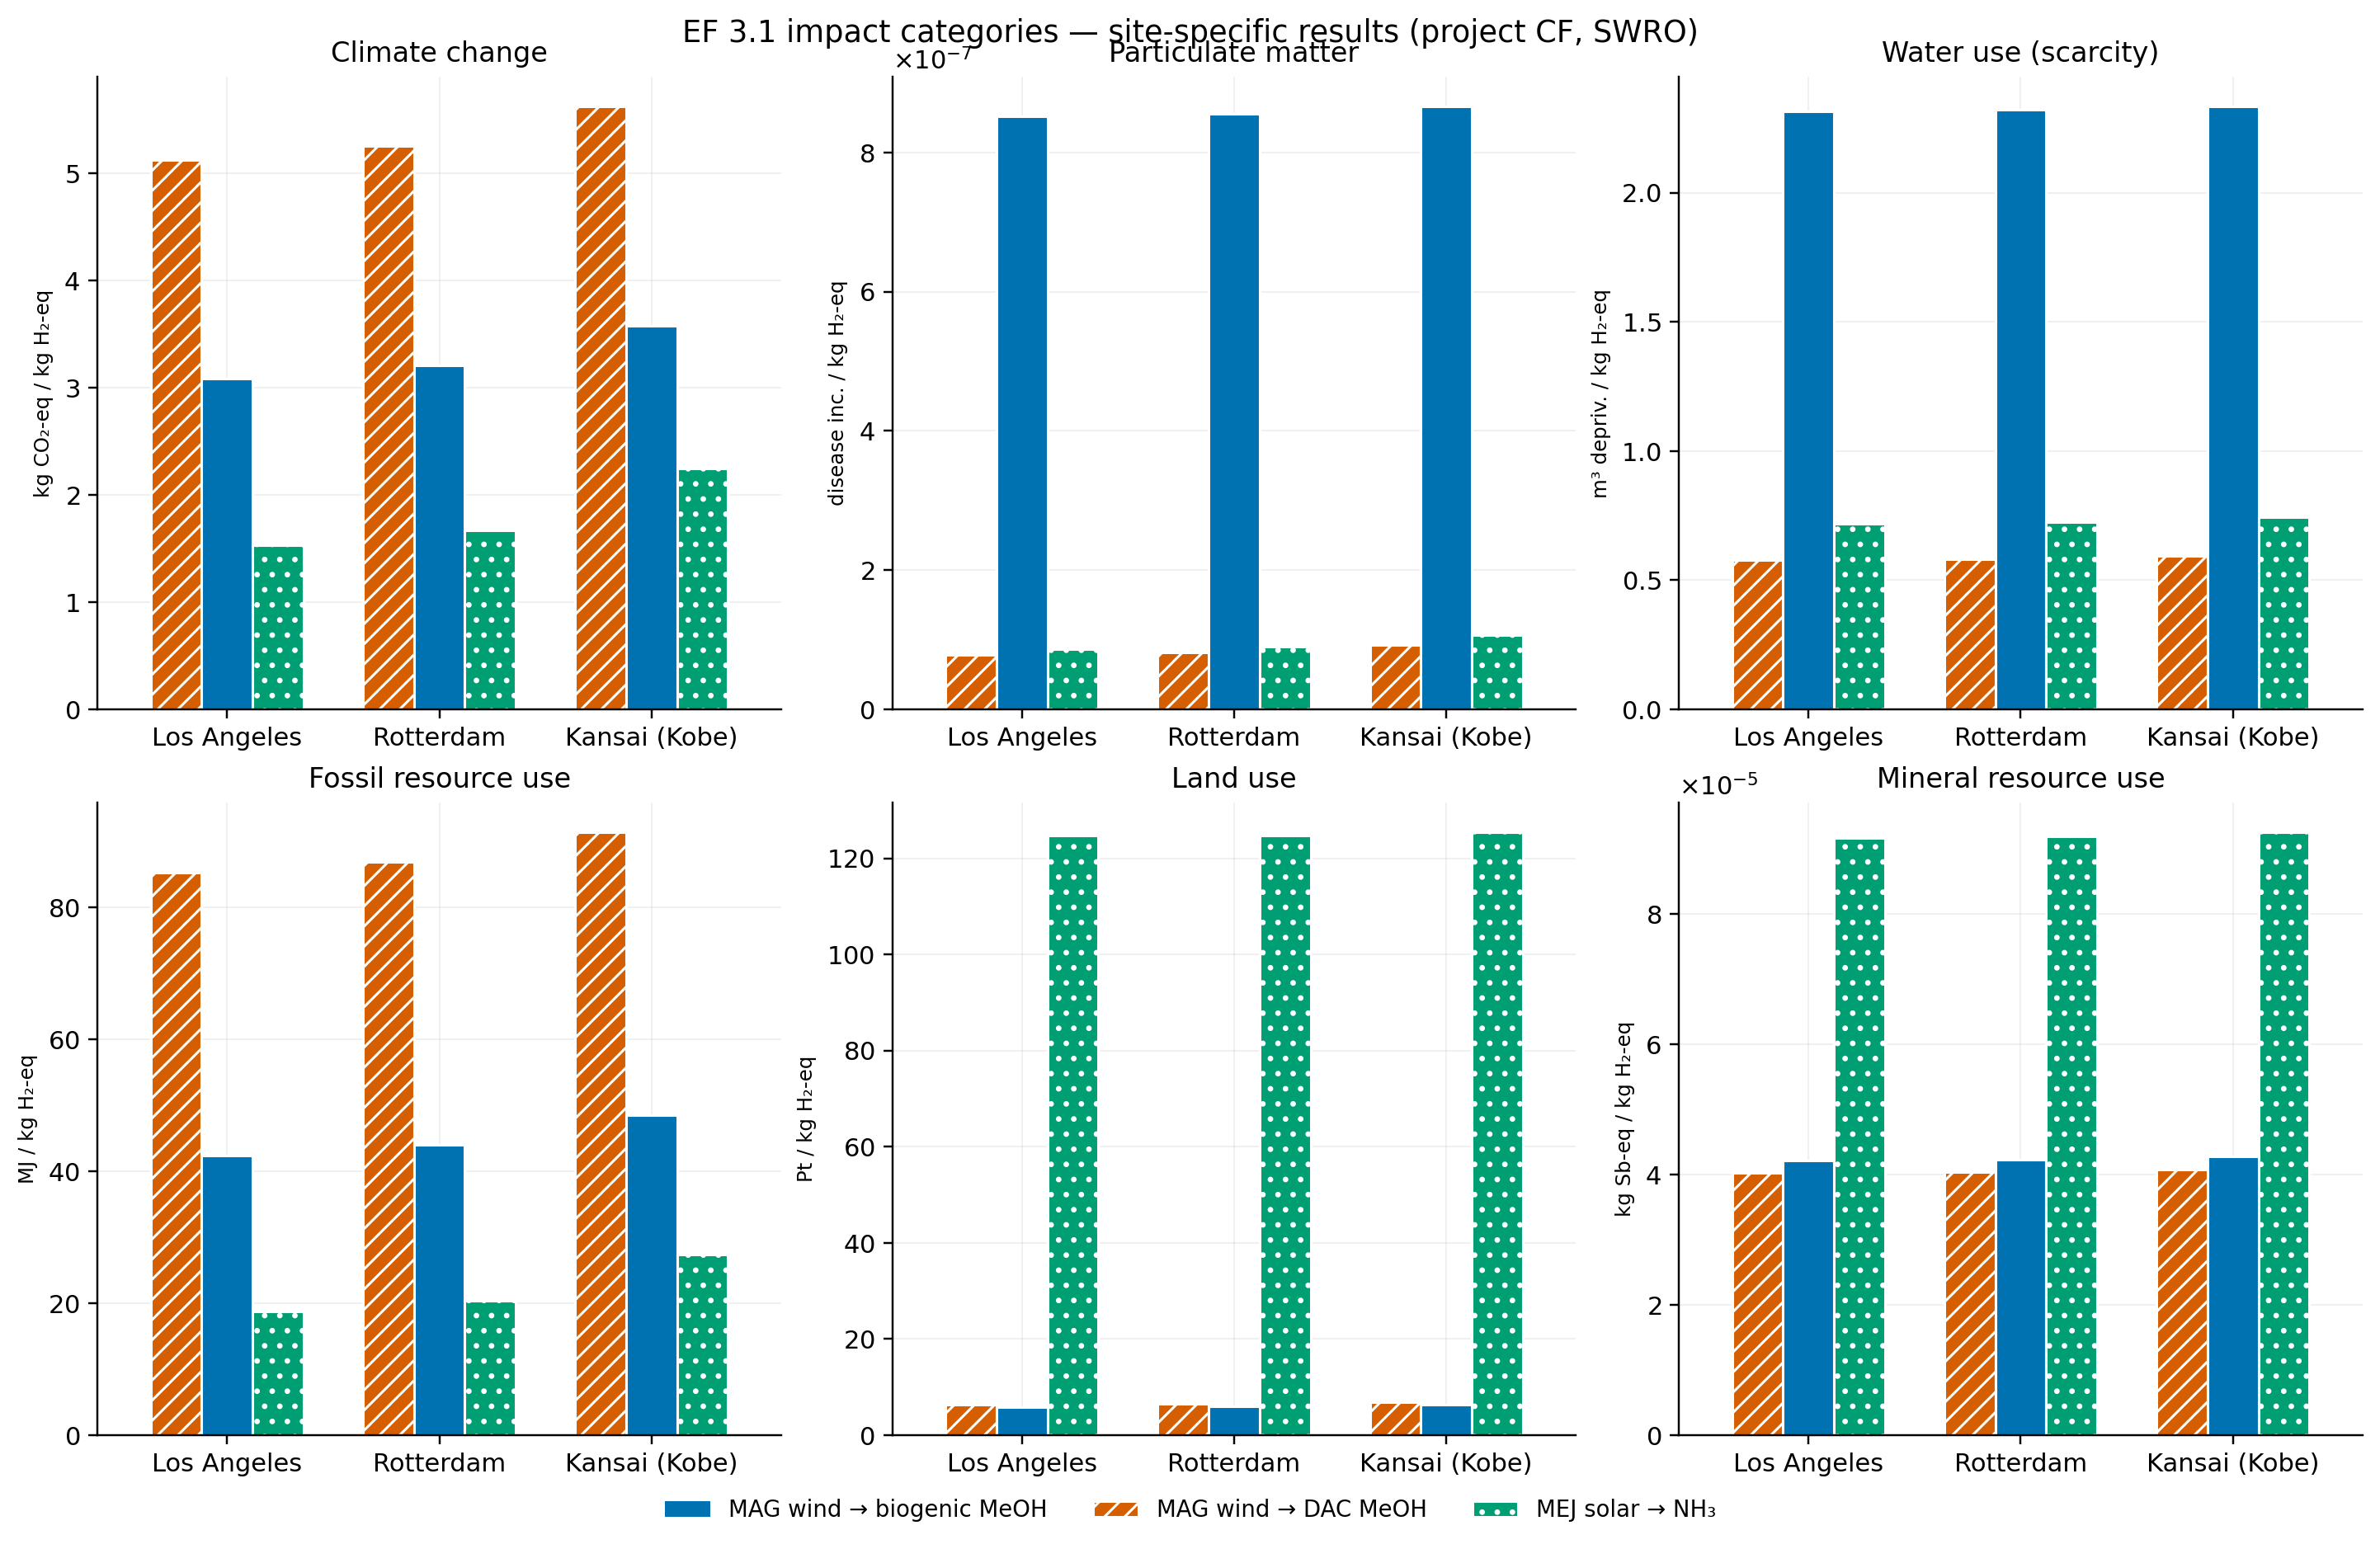

Fig 1 saved


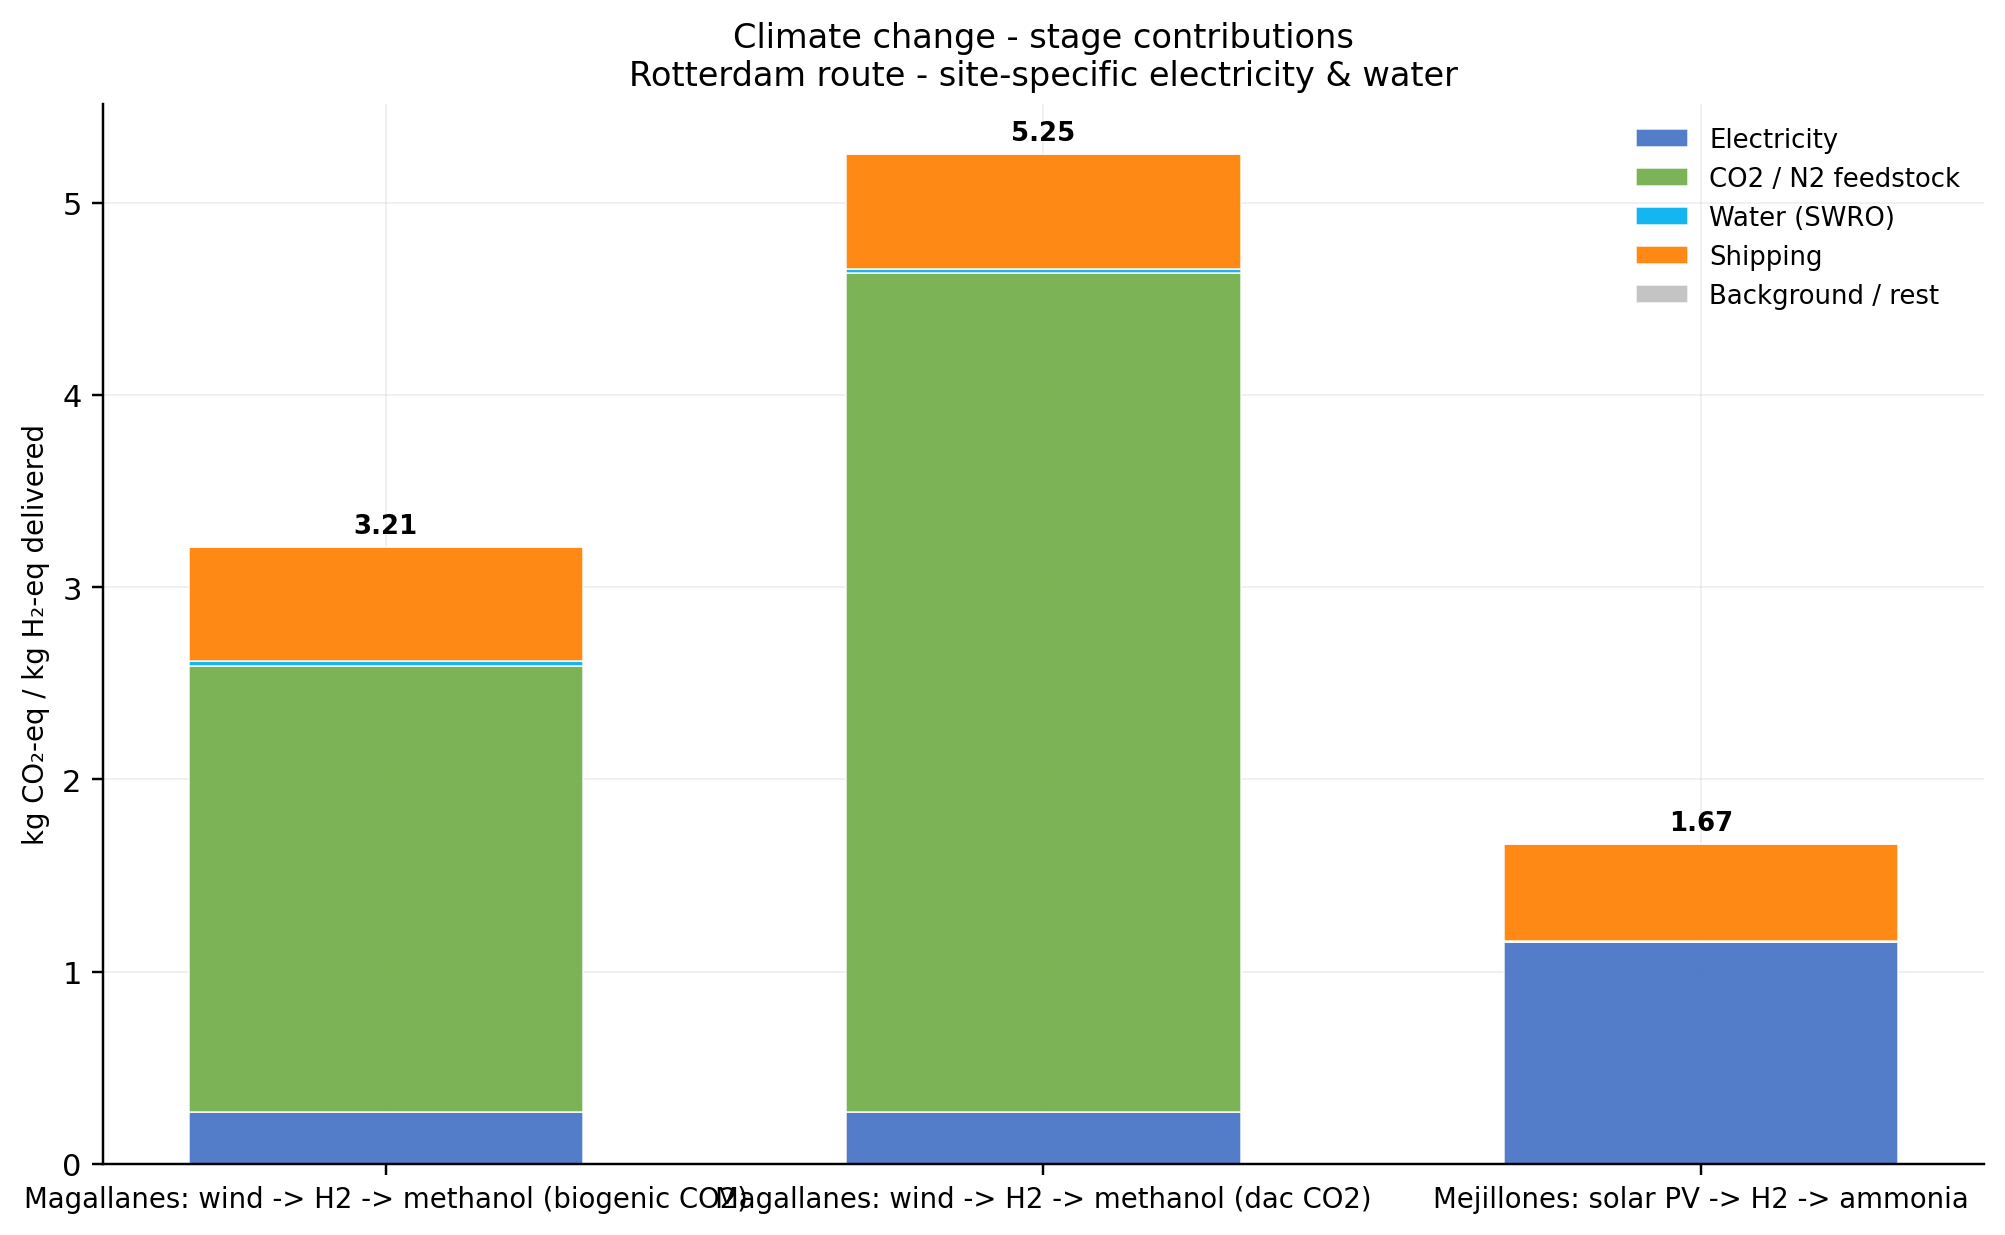

Fig 2 saved


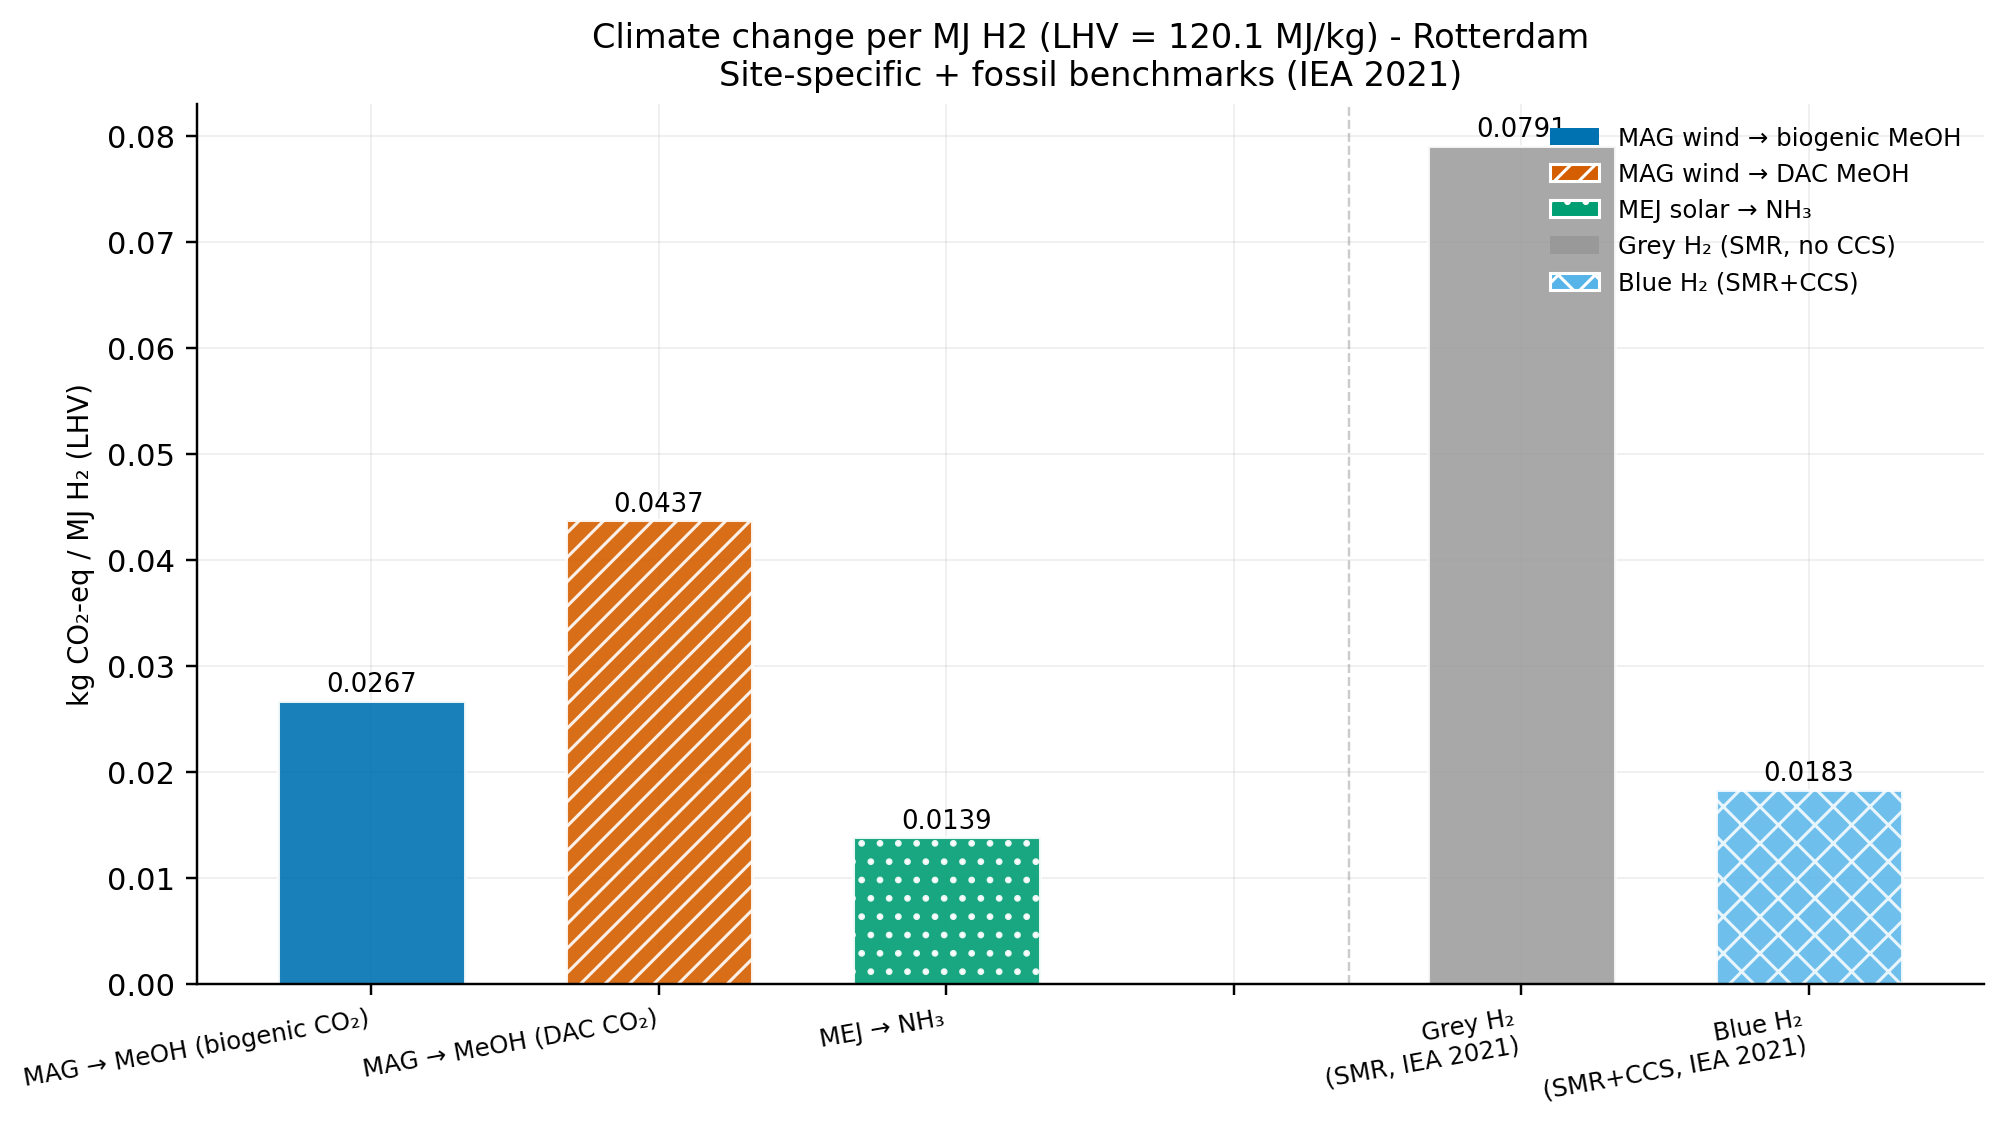

Fig 3 saved


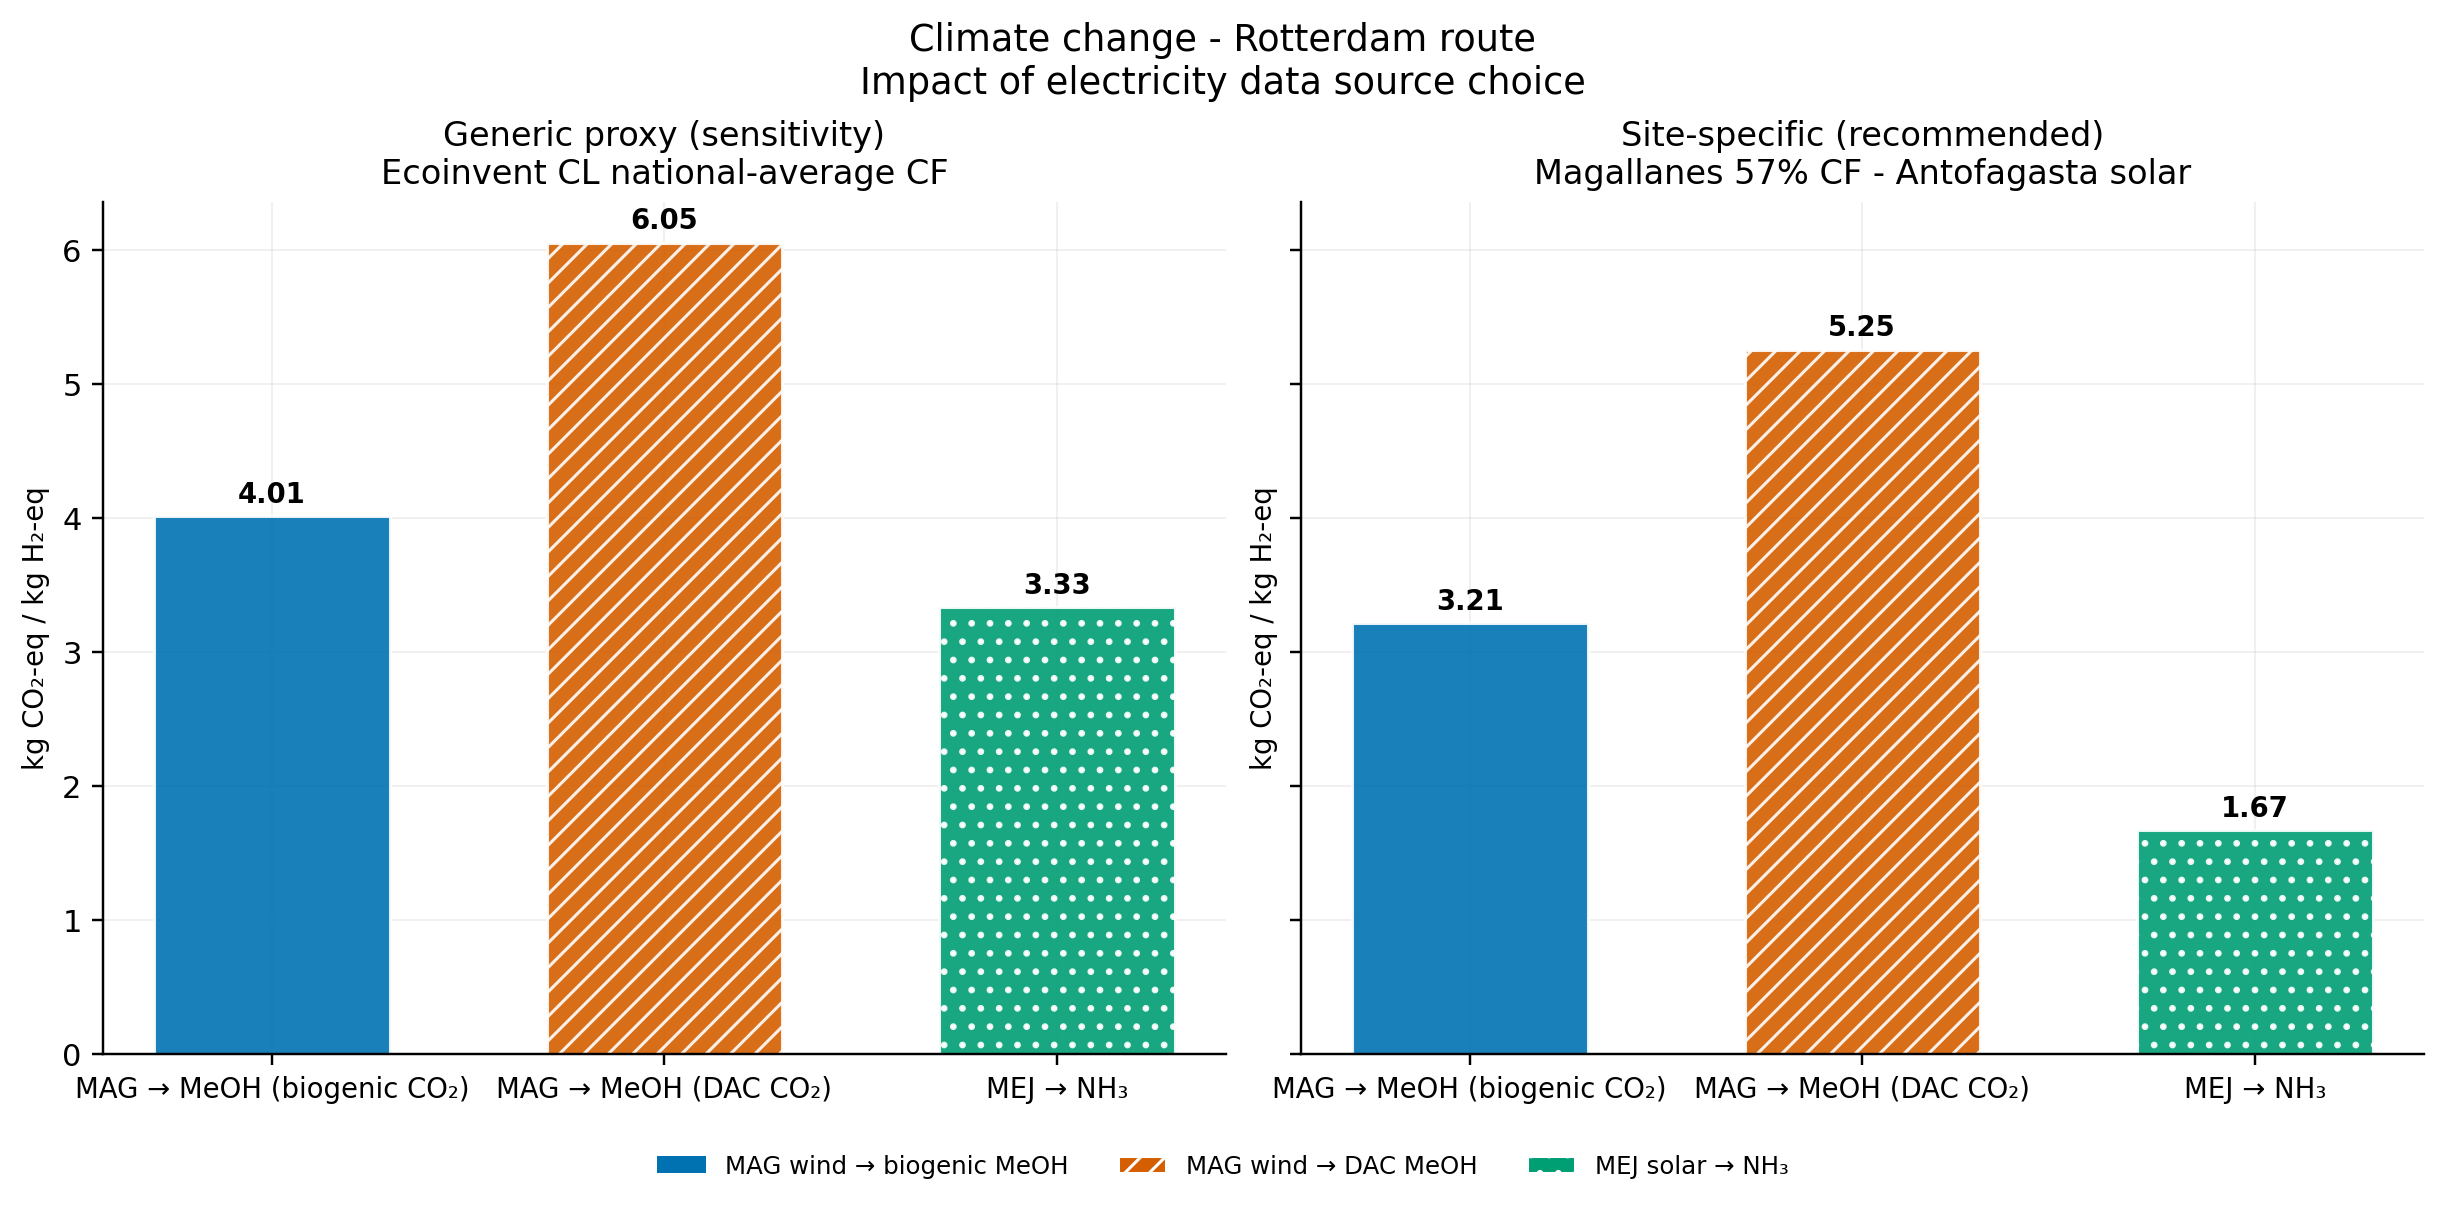

Fig 4 saved


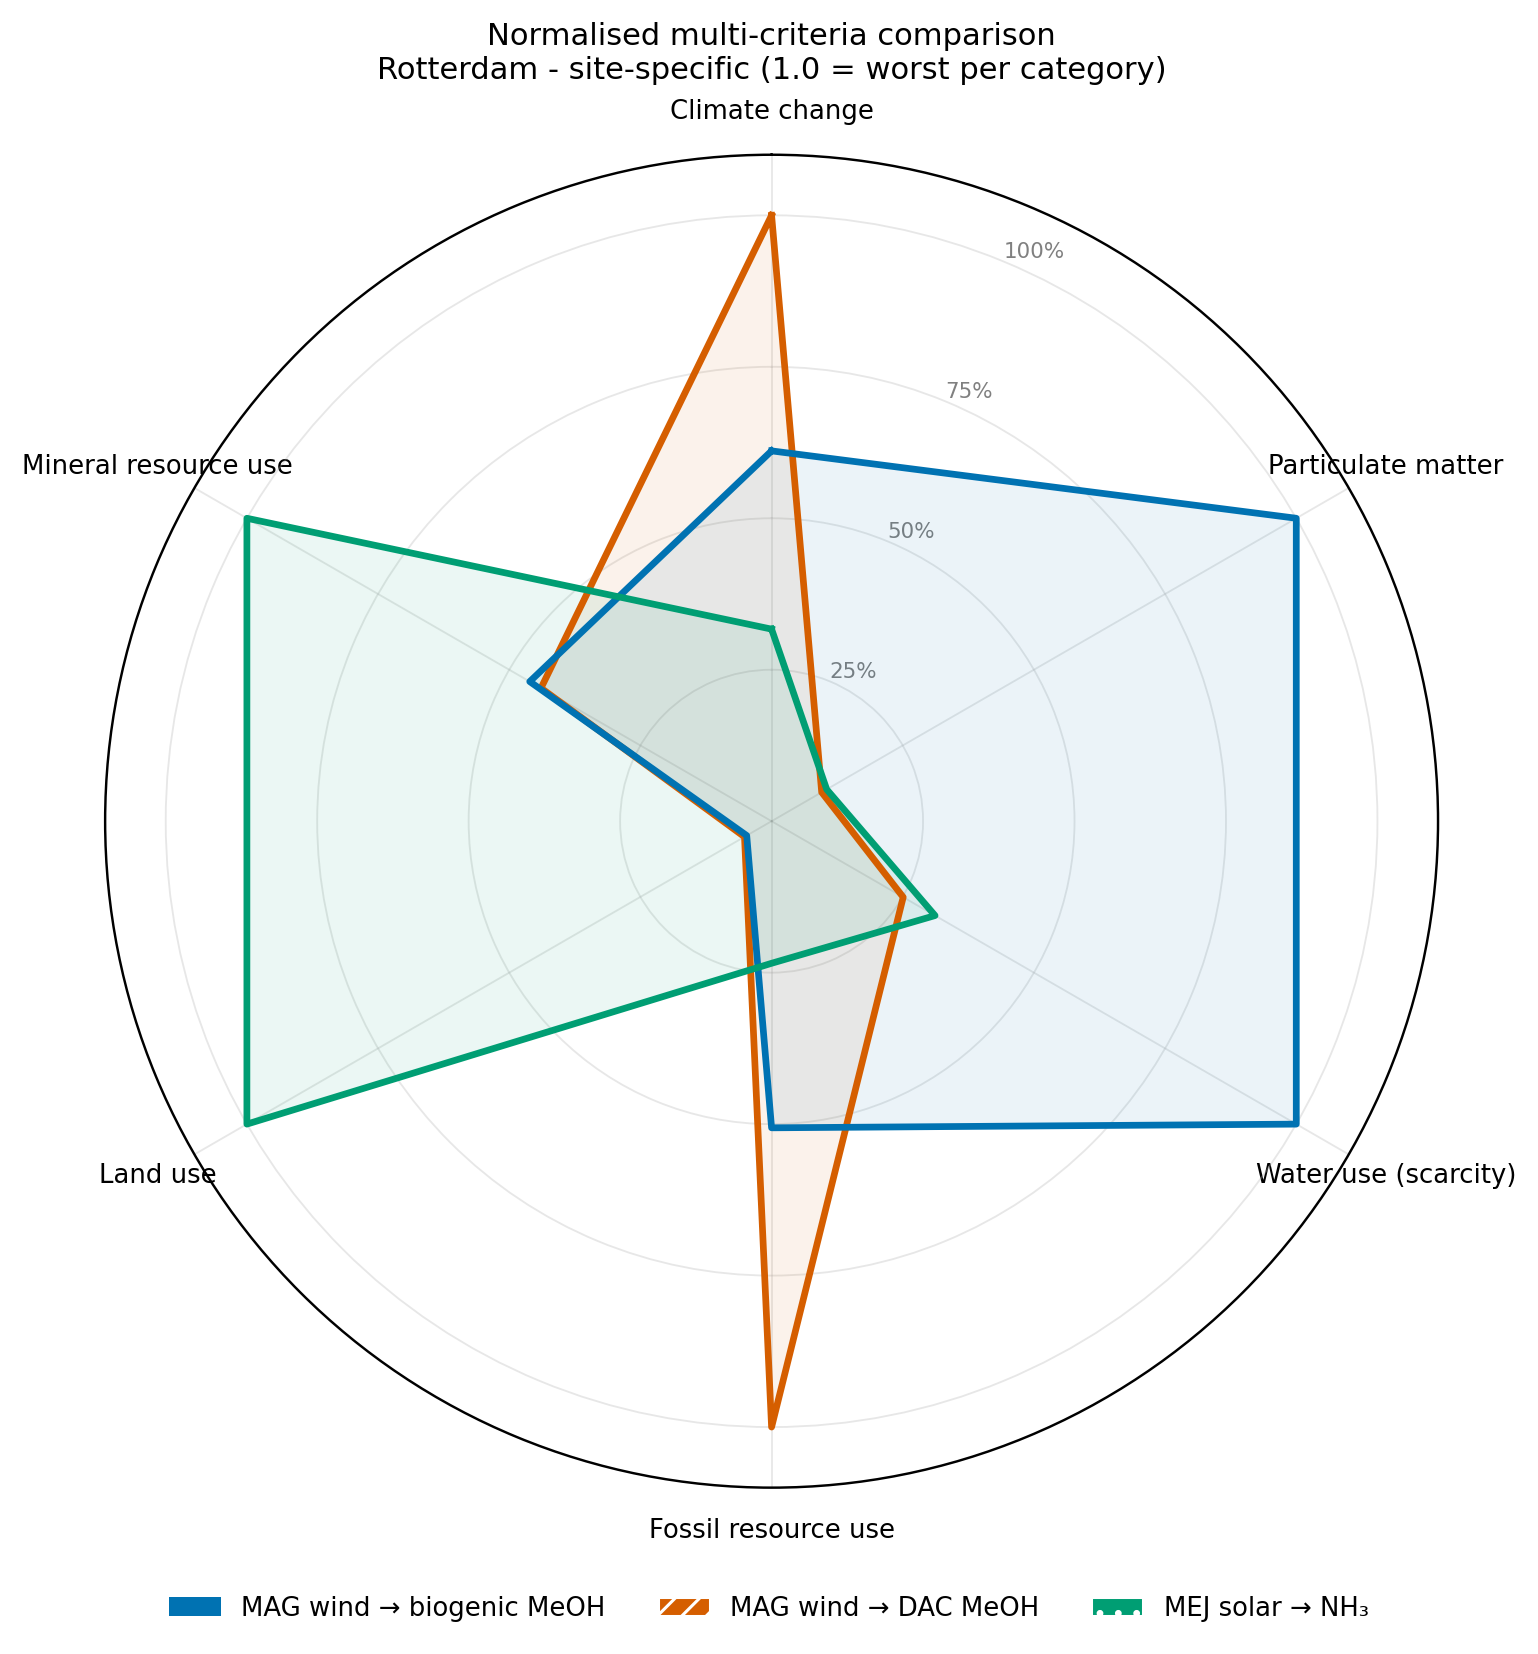

Fig 5 saved

All figures saved to C:\Users\uribep_a\OneDrive - Paul Scherrer Institut\general_LCA\outputs_v11c


In [11]:

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import numpy as np

matplotlib.rcParams.update({
    "font.family" : "DejaVu Sans",
    "font.size"   : 10,
    "axes.titlesize"  : 11,
    "axes.labelsize"  : 9,
    "legend.fontsize" : 8,
    "figure.dpi"  : DPI,
    "savefig.dpi" : 300,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"    : True,
    "grid.alpha"   : 0.20,
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "figure.facecolor": "white",
    "axes.facecolor"  : "white",
})

DEST_ORDER = ["Los Angeles", "Rotterdam", "Kansai (Kobe)"]

# ── Helper: get color and hatch from co2_case ─────────────────────────────────
def pw_color(co2_case):
    return C.get(str(co2_case) if co2_case else "ammonia", "#666666")
def pw_hatch(co2_case):
    return HATCH.get(str(co2_case) if co2_case else "ammonia", "")
def pw_label(row):
    base = str(row["pathway"]).replace("-> H2 ->","→ H₂ →").replace("CO2","CO₂")
    c = row.get("co2_case")
    if c == "biogenic": return base + " (biogenic CO₂)"
    if c == "dac":      return base + " (DAC CO₂)"
    return base  # ammonia

def make_pivot(df, impact, value_col="value"):
    sub = df[df["impact_category"]==impact].copy()
    sub["pw"] = sub.apply(pw_label, axis=1)
    return sub.pivot_table(index="destination", columns="pw", values=value_col).loc[
        [d for d in DEST_ORDER if d in sub["destination"].unique()]]

def barplot(ax, pivot, ylabel="", title="", logy=False):
    cols = list(pivot.columns)
    colors = [pw_color(results_specific_df[results_specific_df.apply(pw_label,axis=1)==c]["co2_case"].iloc[0]
                       if len(results_specific_df[results_specific_df.apply(pw_label,axis=1)==c])>0 else None)
              for c in cols]
    hatches= [pw_hatch(results_specific_df[results_specific_df.apply(pw_label,axis=1)==c]["co2_case"].iloc[0]
                       if len(results_specific_df[results_specific_df.apply(pw_label,axis=1)==c])>0 else None)
              for c in cols]
    pivot.plot(kind="bar", ax=ax, color=colors, width=0.72, edgecolor="none", legend=False)
    for container, h in zip(ax.containers, hatches):
        for patch in container: patch.set_hatch(h); patch.set_edgecolor("white")
    ax.set_xlabel(""); ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(title, pad=6)
    ax.tick_params(axis="x", rotation=0)
    if logy:
        ax.set_yscale("log")
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())

# ── Shared legend patches ─────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor=C["biogenic"], label="MAG wind → biogenic MeOH"),
    mpatches.Patch(facecolor=C["dac"],      hatch="///", edgecolor="white", label="MAG wind → DAC MeOH"),
    mpatches.Patch(facecolor=C["ammonia"],  hatch="..",  edgecolor="white", label="MEJ solar → NH₃"),
]

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — 2×3 grid of all 6 focus impacts
# ─────────────────────────────────────────────────────────────────────────────
FOCUS_DISPLAY = {
    "Climate change"                    : ("Climate change",               "kg CO₂-eq / kg H₂-eq"),
    "Particulate matter"                : ("Particulate matter",           "disease inc. / kg H₂-eq"),
    "Water use"                         : ("Water use (scarcity)",         "m³ depriv. / kg H₂-eq"),
    "Resource use, fossils"             : ("Fossil resource use",          "MJ / kg H₂-eq"),
    "Land use"                          : ("Land use",                     "Pt / kg H₂-eq"),
    "Resource use, minerals and metals" : ("Mineral resource use",         "kg Sb-eq / kg H₂-eq"),
}

fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
axes_flat = axes.ravel()

for ax, (cat, (title, ylabel)) in zip(axes_flat, FOCUS_DISPLAY.items()):
    if cat not in results_specific_df["impact_category"].unique():
        ax.text(0.5, 0.5, f"No data\n{cat}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title); continue
    pivot = make_pivot(results_specific_df, cat)
    barplot(ax, pivot, ylabel=ylabel, title=title)
    # Format y-axis sensibly
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style="sci", axis="y", scilimits=(-3, 3))

fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.04),
           ncol=3, frameon=False, fontsize=9)
fig.suptitle("EF 3.1 impact categories — site-specific results (project CF, SWRO)",
             fontsize=12, y=1.01)
fig.savefig(OUT/"fig_v11c_all6_focus.png",    bbox_inches="tight")
fig.savefig(OUT/"fig_v11c_all6_focus.svg",    bbox_inches="tight")
plt.show(); print("Fig 1 saved")

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2 — CC stacked bar by stage (Rotterdam)
# ─────────────────────────────────────────────────────────────────────────────
STAGE_COLORS = {
    "Electricity"         : "#4472C4",
    "CO2 / N2 feedstock"  : "#70AD47",
    "Water (SWRO)"        : "#00B0F0",
    "Shipping"            : "#FF7F00",
    "Background / rest"   : "#BFBFBF",
}

s_rdam = stage_df[stage_df["destination"]=="Rotterdam"].copy()
s_rdam["pw_sorted"] = s_rdam["pw_label"]
pathways_s = s_rdam["pw_sorted"].unique()
stages_s   = list(STAGE_COLORS.keys())
xs_s = np.arange(len(pathways_s))

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
bottoms = np.zeros(len(pathways_s))
for stage in stages_s:
    sub = s_rdam[s_rdam["stage"]==stage].set_index("pw_sorted").reindex(pathways_s)
    vals = sub["stage_score"].fillna(0).values
    ax.bar(xs_s, vals, bottom=bottoms, color=STAGE_COLORS[stage],
           label=stage, alpha=0.92, edgecolor="white", linewidth=0.5, width=0.6)
    bottoms += vals

for i, (pw, total) in enumerate(zip(pathways_s, s_rdam.groupby("pw_sorted")["site_total"].first().reindex(pathways_s))):
    ax.text(xs_s[i], total + 0.04, f"{total:.2f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

ax.set_xticks(xs_s)
ax.set_xticklabels([p.replace("Magallanes: wind → H₂ → methanol","MAG → MeOH")
                     .replace("Mejillones: solar PV → H₂ → ammonia","MEJ → NH₃")
                     for p in pathways_s], fontsize=9)
ax.set_ylabel("kg CO₂-eq / kg H₂-eq delivered")
ax.set_title("Climate change - stage contributions\nRotterdam route - site-specific electricity & water")
ax.legend(loc="upper right", frameon=False, fontsize=8.5)
fig.savefig(OUT/"fig_v11c_cc_stage_breakdown.png", bbox_inches="tight")
fig.savefig(OUT/"fig_v11c_cc_stage_breakdown.svg", bbox_inches="tight")
plt.show(); print("Fig 2 saved")

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3 — CC per MJ H2 LHV with benchmarks
# ─────────────────────────────────────────────────────────────────────────────
LHV = 120.1  # MJ/kg H2

cc_r = results_specific_df[
    (results_specific_df["impact_category"]=="Climate change") &
    (results_specific_df["destination"]=="Rotterdam")].copy()
cc_r["pw"] = cc_r.apply(pw_label, axis=1)
cc_r["cc_mj"] = cc_r["value"] / LHV

BMKS = [
    ("Grey H₂\n(SMR, IEA 2021)",    9.5 / LHV, C["grey_h2"], ""),
    ("Blue H₂\n(SMR+CCS, IEA 2021)", 2.2 / LHV, C["blue_h2"], "xx"),
]

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
n_pw = len(cc_r)
xs = np.arange(n_pw + len(BMKS) + 1)  # +1 for gap
colors_bar = [pw_color(r["co2_case"]) for _, r in cc_r.iterrows()]
hatches_bar = [pw_hatch(r["co2_case"]) for _, r in cc_r.iterrows()]
labels_bar  = list(cc_r["pw"])

for i, (v, col, h) in enumerate(zip(cc_r["cc_mj"], colors_bar, hatches_bar)):
    b = ax.bar(i, v, color=col, hatch=h, edgecolor="white", width=0.65, alpha=0.9)
    ax.text(i, v+0.0003, f"{v:.4f}", ha="center", va="bottom", fontsize=8.5)

ax.axvline(x=n_pw + 0.4, color="gray", linewidth=0.8, linestyle="--", alpha=0.4)

for j, (label, val, col, h) in enumerate(BMKS):
    xi = n_pw + 1 + j
    b = ax.bar(xi, val, color=col, hatch=h, edgecolor="white", width=0.65, alpha=0.85)
    ax.text(xi, val+0.0003, f"{val:.4f}", ha="center", va="bottom", fontsize=8.5)

all_labels = labels_bar + [""] + [b[0] for b in BMKS]
ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels([l.replace("Magallanes: wind → H₂ → methanol","MAG → MeOH")
                     .replace("Mejillones: solar PV → H₂ → ammonia","MEJ → NH₃")
                     for l in all_labels], fontsize=8, rotation=10, ha="right")
ax.set_ylabel("kg CO₂-eq / MJ H₂ (LHV)")
ax.set_title(f"Climate change per MJ H2 (LHV = {LHV} MJ/kg) - Rotterdam\nSite-specific + fossil benchmarks (IEA 2021)")
ax.legend(handles=legend_handles + [
    mpatches.Patch(facecolor=C["grey_h2"], label="Grey H₂ (SMR, no CCS)"),
    mpatches.Patch(facecolor=C["blue_h2"], hatch="xx", edgecolor="white", label="Blue H₂ (SMR+CCS)"),
], loc="upper right", frameon=False, fontsize=8)
fig.savefig(OUT/"fig_v11c_cc_per_MJ_benchmarks.png", bbox_inches="tight")
fig.savefig(OUT/"fig_v11c_cc_per_MJ_benchmarks.svg", bbox_inches="tight")
plt.show(); print("Fig 3 saved")

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 4 — Generic proxy vs site-specific (Rotterdam CC sensitivity)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True, constrained_layout=True)
for ax, (df_, title_) in zip(axes, [
    (results_generic_df,  "Generic proxy (sensitivity)\nEcoinvent CL national-average CF"),
    (results_specific_df, "Site-specific (recommended)\nMagallanes 57% CF - Antofagasta solar"),
]):
    sub = df_[(df_["impact_category"]=="Climate change")&(df_["destination"]=="Rotterdam")].copy()
    sub["pw"] = sub.apply(pw_label, axis=1)
    pws_ = sub["pw"].unique()
    colors_ = [pw_color(sub[sub["pw"]==p]["co2_case"].iloc[0]) for p in pws_]
    hatches_= [pw_hatch(sub[sub["pw"]==p]["co2_case"].iloc[0]) for p in pws_]
    bars = ax.bar(range(len(pws_)), sub.set_index("pw").loc[pws_,"value"],
                  color=colors_, edgecolor="white", width=0.6, alpha=0.9)
    for bar, h in zip(bars, hatches_): bar.set_hatch(h)
    for i, (bar, pw) in enumerate(zip(bars, pws_)):
        v = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, v+0.06, f"{v:.2f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_xticks(range(len(pws_)))
    ax.set_xticklabels([p.replace("Magallanes: wind → H₂ → methanol","MAG → MeOH")
                         .replace("Mejillones: solar PV → H₂ → ammonia","MEJ → NH₃")
                         for p in pws_], fontsize=9)
    ax.set_ylabel("kg CO₂-eq / kg H₂-eq")
    ax.set_title(title_)

fig.suptitle("Climate change - Rotterdam route\nImpact of electricity data source choice", fontsize=12)
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
fig.savefig(OUT/"fig_v11c_generic_vs_specific.png", bbox_inches="tight")
fig.savefig(OUT/"fig_v11c_generic_vs_specific.svg", bbox_inches="tight")
plt.show(); print("Fig 4 saved")

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 5 — Normalised radar / parallel coordinates (Rotterdam, site-specific)
# ─────────────────────────────────────────────────────────────────────────────
# Radar with all 6 categories normalised within each (0=best, 1=worst across pathways)
rdam = results_specific_df[results_specific_df["destination"]=="Rotterdam"].copy()
rdam["pw"] = rdam.apply(pw_label, axis=1)
pathways_r = sorted(rdam["pw"].unique())

radar_data = {}
for pw in pathways_r:
    sub = rdam[rdam["pw"]==pw].set_index("impact_category")["value"]
    radar_data[pw] = {cat: sub.get(cat, np.nan) for cat in FOCUS}

# Normalise
norm_data = {}
for cat in FOCUS:
    vals = [radar_data[pw][cat] for pw in pathways_r]
    vmax = max(abs(v) for v in vals if not np.isnan(v)) or 1.0
    for pw in pathways_r:
        norm_data.setdefault(pw, {})[cat] = radar_data[pw][cat] / vmax

N = len(FOCUS)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection":"polar"},
                        constrained_layout=True)
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)

label_pad = [list(FOCUS_DISPLAY.values())[i][0] for i in range(N)]
ax.set_xticks(angles[:-1])
ax.set_xticklabels(label_pad, fontsize=8.5)
ax.set_ylim(0, 1.1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%","50%","75%","100%"], fontsize=7, color="gray")
ax.grid(alpha=0.3)

for pw in pathways_r:
    co2 = rdam[rdam["pw"]==pw]["co2_case"].iloc[0] if len(rdam[rdam["pw"]==pw])>0 else None
    vals = [norm_data[pw][cat] for cat in FOCUS] + [norm_data[pw][FOCUS[0]]]
    ax.plot(angles, vals, color=pw_color(co2), linewidth=2.2, linestyle="-")
    ax.fill(angles, vals, color=pw_color(co2), alpha=0.08)

ax.set_title("Normalised multi-criteria comparison\nRotterdam - site-specific (1.0 = worst per category)",
             pad=25, fontsize=10)
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.06),
           ncol=3, frameon=False, fontsize=8.5)
fig.savefig(OUT/"fig_v11c_radar_normalised.png", bbox_inches="tight")
fig.savefig(OUT/"fig_v11c_radar_normalised.svg", bbox_inches="tight")
plt.show(); print("Fig 5 saved")

print()
print(f"All figures saved to {OUT.resolve()}")


## 11 · Export results

In [12]:

out_xlsx = OUT / "GH2_Chile_LCA_v11c_results.xlsx"
with pd.ExcelWriter(out_xlsx, engine="openpyxl") as w:
    results_specific_df.to_excel(w, sheet_name="site_specific", index=False)
    results_generic_df.to_excel(w, sheet_name="generic_proxy", index=False)
    stage_df.to_excel(w, sheet_name="stage_contributions", index=False)
    delivered_df.to_excel(w, sheet_name="delivered_activities", index=False)
    pd.DataFrame(selected_proxies := [{"proxy":k,"name":v.get("name") if v else "None",
        "loc":v.get("location") if v else "-","unit":v.get("unit") if v else "-"}
        for k,v in PX.items()]).to_excel(w, sheet_name="proxies", index=False)
    # Key results pivot for paper
    cc_pivot = results_specific_df.pivot_table(
        index="impact_category", columns=["co2_case","destination"], values="value").round(5)
    cc_pivot.to_excel(w, sheet_name="all_results_pivot")
print(f"Exported: {out_xlsx.resolve()}")


Exported: C:\Users\uribep_a\OneDrive - Paul Scherrer Institut\general_LCA\outputs_v11c\GH2_Chile_LCA_v11c_results.xlsx


## 12 · Validation

In [13]:

print("=" * 55)
print(f"  V11c VALIDATION SUMMARY")
print("=" * 55)
checks = [
    ("Delivered activities",            len(delivered_df),                        9),
    ("Generic results rows",            len(results_generic_df),                  54),
    ("Site-specific results rows",      len(results_specific_df),                 54),
    ("Focus methods matched",           sum(1 for c in FOCUS if METHOD_MAP.get(c)),6),
    ("Stage rows (Rotterdam)",          len(stage_df[stage_df["destination"]=="Rotterdam"]),None),
    ("Figures saved",                   len(list(OUT.glob("fig_v11c*.png"))),      None),
]
all_pass = True
for label, got, expected in checks:
    ok = (got == expected) if expected else True
    all_pass = all_pass and ok
    icon = "OK" if ok else "!!"
    exp_str = f"/{expected}" if expected else ""
    print(f"  [{icon}] {label:<40s}: {got}{exp_str}")
print()
print("  STATUS:", "PASS" if all_pass else "FAIL — check items marked !!")
print("=" * 55)


  V11c VALIDATION SUMMARY
  [OK] Delivered activities                    : 9/9
  [OK] Generic results rows                    : 54/54
  [OK] Site-specific results rows              : 54/54
  [OK] Focus methods matched                   : 6/6
  [OK] Stage rows (Rotterdam)                  : 15
  [OK] Figures saved                           : 5

  STATUS: PASS
